# Contrastive Experiments Analysis

This notebook analyzes the performance of different contrastive experiments using the Qwen3-14B model. We compare different non-activating sources (random, co-occurrence, faiss, decoder_similarity) and ranking strategies (top vs quantiles) across multiple metrics.

## Analysis Overview

- **Mean Frequency-Weighted F1 Scores**: Bar charts comparing performance across configurations
- **Performance Distribution**: KDE plots showing density distributions of F1 scores
- **Comprehensive Comparison**: Side-by-side analysis of all available contrastive experiments

## Configuration Pattern

Experiments follow the pattern: `{model}_{source}_{mode}_{ranking}`
- **Sources**: random (baseline), co-occurrence, faiss, decoder_similarity
- **Modes**: contrastive_scorer_only, baseline
- **Ranking**: top, quantiles

## 1. Setup and Configuration

Import required libraries and set up the analysis environment.

In [7]:
import sys
import os
import json
from pathlib import Path
import pandas as pd
import numpy as np
import torch
from scipy import stats
from tqdm.auto import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

# Add the parent directory to the path to import delphi modules
sys.path.append(str(Path.cwd().parent))

from delphi.log.result_analysis import (
    import_plotly,
    load_data,
    get_agg_metrics,
    add_latent_f1,
    compute_confusion,
    compute_classification_metrics,
    frequency_weighted_f1
)

# Import plotly for plotting
px = import_plotly()

# Configuration
EXPERIMENT_DIR = "Contrastive Experiments"
CONFIDENCE_LEVEL = 0.95
ENABLE_BOOTSTRAP = True
BOOTSTRAP_SAMPLES = 2000

# Set up directories
results_dir = Path.cwd().parent / "results"
visualizations_dir = results_dir / "visualizations" / "contrastive_experiments"
visualizations_dir.mkdir(exist_ok=True, parents=True)

print(f"Experiment directory: {EXPERIMENT_DIR}")
print(f"Results directory: {results_dir}")
print(f"Visualizations output: {visualizations_dir}")

# Define color scheme for different experiment types
SOURCE_COLORS = {
    'random': '#E53E3E',        # Red for baseline
    'co-occurrence': '#3182CE', # Blue
    'faiss': '#38A169',         # Green  
    'decoder_similarity': '#805AD5'  # Purple
}

RANKING_STYLES = {
    'top': 'solid',
    'quantiles': 'dashed'
}

# Clean display name mappings
SOURCE_DISPLAY = {
    'random': 'Random',
    'co-occurrence': 'Co-occurrence',
    'faiss': 'FAISS',
    'decoder_similarity': 'Decoder Sim.'
}

RANKING_DISPLAY = {
    'top': 'Top',
    'quantiles': 'Quantiles'
}

def parse_experiment_name(exp_name):
    """Parse experiment directory name to extract components."""
    # Remove pythiaST_ prefix
    name = exp_name.replace('pythiaST_', '')
    
    # Extract components
    parts = name.split('_')
    
    # Find the source (random, co-occurrence, faiss, decoder)
    source = None
    if 'random' in name:
        source = 'random'
    elif 'co-occurrence' in name:
        source = 'co-occurrence'
    elif 'faiss' in name:
        source = 'faiss'
    elif 'decoder' in name:
        source = 'decoder_similarity'
    
    # Find the ranking strategy
    ranking = 'quantiles' if 'quantiles' in name else 'top'
    
    # Determine mode
    mode = 'baseline' if 'baseline' in name else 'contrastive'
    
    # Create clean display name
    source_display = SOURCE_DISPLAY.get(source, source)
    ranking_display = RANKING_DISPLAY.get(ranking, ranking)
    display_name = f"{source_display} ({ranking_display})"
    
    return {
        'source': source,
        'ranking': ranking,
        'mode': mode,
        'display_name': display_name
    }

# Check available experiments
experiments_base = results_dir / "pythiaST" / EXPERIMENT_DIR
if experiments_base.exists():
    print(f"\nAvailable contrastive experiments:")
    for exp_dir in sorted(experiments_base.glob('pythiaST_*')):
        config = parse_experiment_name(exp_dir.name)
        print(f"  - {exp_dir.name} -> {config['display_name']}")
else:
    print(f"Warning: Experiments directory not found: {experiments_base}")

Experiment directory: Contrastive Experiments
Results directory: /home/jeremias/projects/delphi-explanations/results
Visualizations output: /home/jeremias/projects/delphi-explanations/results/visualizations/contrastive_experiments

Available contrastive experiments:
  - pythiaST_Qwen3_14B_quantized_w4a16_co-occurrence_contrastive_scorer_only_quantiles -> Co-occurrence (Quantiles)
  - pythiaST_Qwen3_14B_quantized_w4a16_co-occurrence_contrastive_scorer_only_top -> Co-occurrence (Top)
  - pythiaST_Qwen3_14B_quantized_w4a16_decoder_similarity_contrastive_scorer_only_quantiles -> Decoder Sim. (Quantiles)
  - pythiaST_Qwen3_14B_quantized_w4a16_decoder_similarity_contrastive_scorer_only_top -> Decoder Sim. (Top)
  - pythiaST_Qwen3_14B_quantized_w4a16_faiss_contrastive_scorer_only_quantiles -> FAISS (Quantiles)
  - pythiaST_Qwen3_14B_quantized_w4a16_faiss_contrastive_scorer_only_top -> FAISS (Top)
  - pythiaST_Qwen3_14B_quantized_w4a16_random_baseline_quantiles -> Random (Quantiles)
  - pythia

## 2. Load Contrastive Experiment Results

Load results from all available contrastive experiments and process them for analysis.

In [8]:
def load_contrastive_results(results_dir: Path, experiment_dir: str):
    """Load results from all contrastive experiments."""
    experiment_results = {}
    experiment_stats = {}
    
    experiments_base = results_dir / "pythiaST" / experiment_dir
    
    if not experiments_base.exists():
        print(f"Warning: Experiments directory not found: {experiments_base}")
        return experiment_results, experiment_stats
    
    for exp_dir in experiments_base.glob('pythiaST_*'):
        config = parse_experiment_name(exp_dir.name)
        display_name = config['display_name']
        
        scores_path = exp_dir / "scores"
        if scores_path.exists():
            try:
                # Use the shared cache from the parent pythiaST directory
                latents_path = results_dir / "pythiaST" / "cache" / "latents"
                if not latents_path.exists():
                    latents_path = exp_dir / "latents"  # Fallback to local latents
                
                if latents_path.exists():
                    # Extract module names from the actual files
                    sample_score_dir = next(scores_path.iterdir())
                    sample_files = list(sample_score_dir.glob("*.txt"))
                    if sample_files:
                        # Extract module name from filename pattern
                        sample_filename = sample_files[0].stem
                        module_name = sample_filename.split('_latent')[0]
                        modules = [module_name]
                    else:
                        print(f"No score files found in {sample_score_dir}")
                        continue
                    
                    # Use load_data from result_analysis.py
                    latent_df, counts = load_data(scores_path, latents_path, modules)
                    
                    if latent_df.empty:
                        print(f"No data found for {display_name}")
                        continue
                    
                    # Use add_latent_f1 and get_agg_metrics from result_analysis.py
                    latent_df = add_latent_f1(latent_df)
                    processed_df = get_agg_metrics(latent_df, counts)
                    
                    experiment_results[display_name] = {
                        'latent_df': latent_df,
                        'processed_df': processed_df,
                        'counts': counts,
                        'config': config
                    }
                else:
                    print(f"Latents path not found for {display_name}")
            
            except Exception as e:
                print(f"Error loading results for {exp_dir.name}: {e}")
                continue
        
        # Load experiment statistics
        stats_file = exp_dir / "explainer_stats.json"
        if stats_file.exists():
            try:
                with open(stats_file, 'r') as f:
                    stats = json.load(f)
                    experiment_stats[display_name] = stats
            except Exception as e:
                print(f"Error loading stats for {exp_dir.name}: {e}")
                experiment_stats[display_name] = None
        else:
            experiment_stats[display_name] = None
    
    return experiment_results, experiment_stats

# Load all contrastive experiment results
print("Loading contrastive experiment results...")
experiment_results, experiment_stats = load_contrastive_results(results_dir, EXPERIMENT_DIR)

print(f"\nLoaded results for {len(experiment_results)} experiments:")
for exp_name in experiment_results.keys():
    print(f"  - {exp_name}")

# Display sample metrics for the first experiment
if experiment_results:
    sample_exp = list(experiment_results.keys())[0]
    sample_data = experiment_results[sample_exp]['processed_df']
    print(f"\nSample metrics from {sample_exp}:")
    print(sample_data[['score_type', 'accuracy', 'f1_score', 'precision', 'recall', 'weighted_f1']].round(3))

Loading contrastive experiment results...


/home/jeremias/projects/delphi-explanations/delphi/log/result_analysis.py:444: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

/home/jeremias/projects/delphi-explanations/delphi/log/result_analysis.py:444: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

/home/jeremias/projects/delphi-explanations/delphi/log/result_analysis.py:444: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is d


Loaded results for 7 experiments:
  - FAISS (Quantiles)
  - Co-occurrence (Quantiles)
  - Decoder Sim. (Quantiles)
  - Co-occurrence (Top)
  - Decoder Sim. (Top)
  - Random (Quantiles)
  - Random (Top)

Sample metrics from FAISS (Quantiles):
  score_type  accuracy  f1_score  precision  recall  weighted_f1
0  detection     0.723     0.718      0.733   0.703        0.626
1       fuzz     0.825     0.808      0.896   0.736        0.594


## 3. Generate Mean Frequency-Weighted F1 Bar Charts

Create bar charts showing mean frequency-weighted F1 scores across all contrastive experiments, organized by source and ranking strategy.

In [9]:
# Reuse bootstrap functions from the original notebook
def compute_per_module_f1s(score_subset, counts):
    """Return list of per-module frequency-weighted F1 values computed from the given score_subset."""
    rows = []
    for (module, latent_idx), grp in score_subset.groupby(["module", "latent_idx"]):
        if module in counts and latent_idx < len(counts[module]):
            f1 = compute_classification_metrics(compute_confusion(grp))["f1_score"]
            fire = counts[module][latent_idx].item()
            rows.append({"module": module, "latent_idx": latent_idx, "f1_score": f1, "firing_count": fire})
    if not rows:
        return []
    df = pd.DataFrame(rows)
    per_module_vals = []
    for module in df['module'].unique():
        mdf = df[df['module'] == module]
        firing_weights = counts[module][mdf['latent_idx']].float()
        total_weight = firing_weights.sum()
        if total_weight > 0:
            f1_tensor = torch.as_tensor(mdf['f1_score'].values, dtype=torch.float32)
            module_f1 = (f1_tensor * firing_weights).sum() / firing_weights.sum()
            per_module_vals.append(module_f1.item())
    return per_module_vals

def run_bootstrap_single_thread_optimized(score_subset, counts, n_boot, confidence):
    """Optimized bootstrap using multinomial sampling on precomputed latents."""
    grouped = list(score_subset.groupby(["module", "latent_idx"]))
    
    latent_f1s = []
    latent_weights = []
    module_names = []
    
    for (module, latent_idx), grp in grouped:
        if module in counts and latent_idx < len(counts[module]):
            f1 = compute_classification_metrics(compute_confusion(grp))["f1_score"]
            fire_count = counts[module][latent_idx].item()
            latent_f1s.append(float(f1))
            latent_weights.append(float(fire_count))
            module_names.append(module)
    
    if not latent_f1s:
        return []
    
    latent_f1s = np.asarray(latent_f1s, dtype=np.float64)
    latent_weights = np.asarray(latent_weights, dtype=np.float64)
    unique_modules, module_ids = np.unique(module_names, return_inverse=True)
    num_modules = len(unique_modules)
    num_latents = len(latent_f1s)
    
    samples = []
    
    for i in tqdm(range(n_boot), desc=f"Bootstrapping ({n_boot})", leave=False):
        boot_counts = np.random.multinomial(num_latents, [1.0 / num_latents] * num_latents)
        
        numerator = np.bincount(module_ids, weights=latent_f1s * latent_weights * boot_counts, minlength=num_modules)
        denominator = np.bincount(module_ids, weights=latent_weights * boot_counts, minlength=num_modules)
        
        per_module_f1s = np.divide(numerator, denominator, out=np.zeros_like(numerator), where=denominator != 0)
        samples.append(float(per_module_f1s.mean()))
    
    return samples

def compute_ci_from_samples(samples, freq_weighted_f1, confidence):
    """Compute confidence interval errors from bootstrap samples."""
    if not samples:
        return 0.0, 0.0
    lower_pct = (1.0 - confidence) / 2.0 * 100.0
    upper_pct = (1.0 + confidence) / 2.0 * 100.0
    lower_ci, upper_ci = np.percentile(samples, [lower_pct, upper_pct])
    return float(freq_weighted_f1 - lower_ci), float(upper_ci - freq_weighted_f1)

def compute_contrastive_error_bars(experiment_results, score_type, enable_bootstrap=ENABLE_BOOTSTRAP, n_boot=BOOTSTRAP_SAMPLES, confidence=CONFIDENCE_LEVEL):
    """Compute frequency-weighted F1 and CI errors for contrastive experiments."""
    rows = []
    for exp_name, data in experiment_results.items():
        processed_df = data['processed_df']
        score_row = processed_df[processed_df['score_type'] == score_type]
        if len(score_row) == 0:
            continue
        freq_weighted_f1 = score_row['weighted_f1'].iloc[0] if 'weighted_f1' in score_row.columns else None
        latent_df = data['latent_df']
        counts = data['counts']
        config = data['config']
        score_subset = latent_df[latent_df['score_type'] == score_type]
        
        if len(score_subset) == 0 or counts is None or freq_weighted_f1 is None:
            rows.append({
                'experiment': config['display_name'],  # Use clean display name
                'source': config['source'],
                'ranking': config['ranking'],
                'mode': config['mode'],
                'frequency_weighted_f1': freq_weighted_f1,
                'ci_lower_error': 0.0,
                'ci_upper_error': 0.0
            })
            continue
        
        if enable_bootstrap:
            samples = run_bootstrap_single_thread_optimized(score_subset, counts, n_boot, confidence)
            ci_lower_error, ci_upper_error = compute_ci_from_samples(samples, freq_weighted_f1, confidence)
        else:
            ci_lower_error = 0.0
            ci_upper_error = 0.0
        
        rows.append({
            'experiment': config['display_name'],  # Use clean display name
            'source': config['source'],
            'ranking': config['ranking'],
            'mode': config['mode'],
            'frequency_weighted_f1': float(freq_weighted_f1),
            'ci_lower_error': ci_lower_error,
            'ci_upper_error': ci_upper_error
        })
    
    return pd.DataFrame(rows)

# Generate bar charts for each score type
all_score_types = set()
for data in experiment_results.values():
    all_score_types.update(list(data['processed_df']['score_type'].unique()))
all_score_types = sorted(list(all_score_types))

print(f"Generating bar charts for score types: {all_score_types}")

# Compute error bars for all score types
contrastive_error_tables = {}
for st in all_score_types:
    print(f"Computing error bars for {st} (bootstrap={ENABLE_BOOTSTRAP})")
    contrastive_error_tables[st] = compute_contrastive_error_bars(experiment_results, st)

def score_display_name(st):
    return 'Fuzzing' if str(st).lower() == 'fuzz' else str(st).title()

# Create bar charts
for score_type, error_df in contrastive_error_tables.items():
    if error_df.empty:
        continue
    
    # Sort by frequency_weighted_f1 for better visualization
    error_df = error_df.sort_values('frequency_weighted_f1', ascending=False)
    
    # Create colors based on source
    colors = [SOURCE_COLORS.get(source, '#808080') for source in error_df['source']]
    
    fig = px.bar(
        error_df,
        x='experiment',
        y='frequency_weighted_f1',
        color='source',
        color_discrete_map=SOURCE_COLORS,
        title=f'Contrastive Experiments: Frequency-Weighted F1 Score - {score_display_name(score_type)} ({int(CONFIDENCE_LEVEL*100)}% CI)',
        text='frequency_weighted_f1',
        hover_data=['ranking', 'mode']
    )
    
    # Add error bars
    fig.update_traces(
        error_y=dict(
            type='data',
            symmetric=False,
            array=error_df['ci_upper_error'],
            arrayminus=error_df['ci_lower_error']
        )
    )
    
    fig.update_layout(
        yaxis_range=[0, 1],
        xaxis_title="Experiment Configuration",
        yaxis_title=f"Frequency-Weighted F1 Score ({int(CONFIDENCE_LEVEL*100)}% CI)",
        xaxis={'tickangle': 45},
        height=600,
        legend_title="Non-Activating Source"
    )
    
    fig.update_traces(texttemplate='%{text:.3f}', textposition='outside')
    fig.show()
    
    # Save the chart
    output_file_pdf = visualizations_dir / f"contrastive_freq_weighted_f1_bar_{score_type}.pdf"
    output_file_png = visualizations_dir / f"contrastive_freq_weighted_f1_bar_{score_type}.png"
    fig.write_image(str(output_file_pdf))
    fig.write_image(str(output_file_png))
    print(f"Saved contrastive F1 bar chart: {output_file_pdf}")

print(f"\nBar charts saved to {visualizations_dir}")

Generating bar charts for score types: ['detection', 'fuzz']
Computing error bars for detection (bootstrap=True)


Bootstrapping (2000):   0%|          | 0/2000 [00:00<?, ?it/s]

Bootstrapping (2000):   0%|          | 0/2000 [00:00<?, ?it/s]

Bootstrapping (2000):   0%|          | 0/2000 [00:00<?, ?it/s]

Bootstrapping (2000):   0%|          | 0/2000 [00:00<?, ?it/s]

...

/tmp/ipykernel_1620453/767532177.py:180: DeprecationWarning:


Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).




Saved contrastive F1 bar chart: /home/jeremias/projects/delphi-explanations/results/visualizations/contrastive_experiments/contrastive_freq_weighted_f1_bar_detection.pdf


/tmp/ipykernel_1620453/767532177.py:181: DeprecationWarning:


Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).




/tmp/ipykernel_1620453/767532177.py:180: DeprecationWarning:


Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).


/tmp/ipykernel_1620453/767532177.py:181: DeprecationWarning:


Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).




Saved contrastive F1 bar chart: /home/jeremias/projects/delphi-explanations/results/visualizations/contrastive_experiments/contrastive_freq_weighted_f1_bar_fuzz.pdf

Bar charts saved to /home/jeremias/projects/delphi-explanations/results/visualizations/contrastive_experiments


## 4. Generate KDE Distribution Plots

Create kernel density estimation plots showing the distribution of F1 scores across different experimental configurations.

Generating KDE plots for detection...


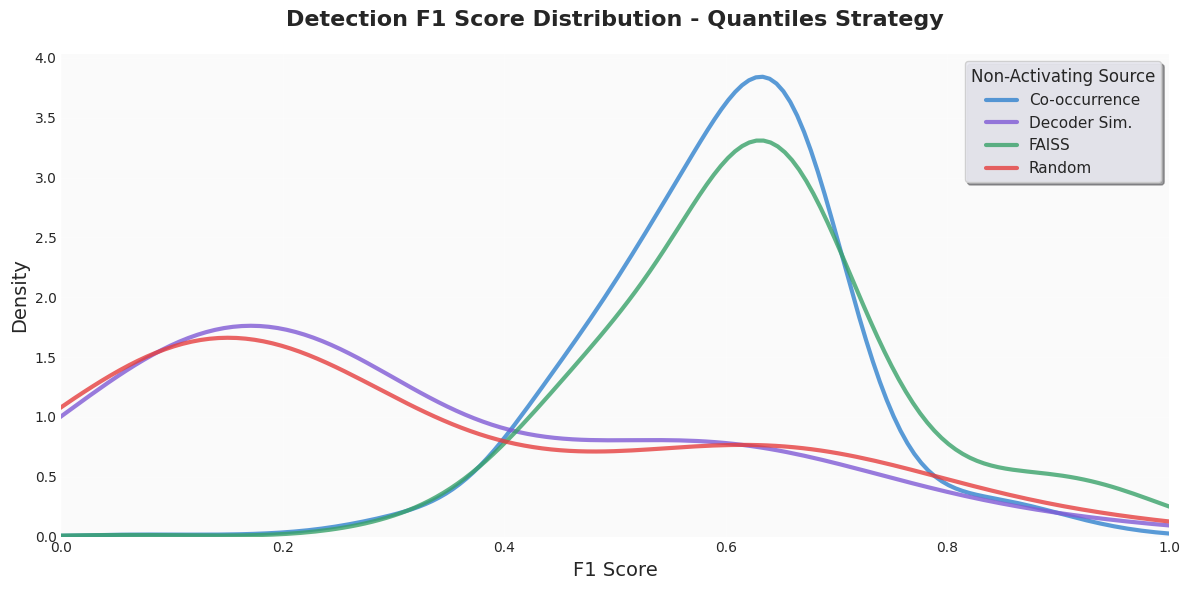

Saved KDE plot: /home/jeremias/projects/delphi-explanations/results/visualizations/contrastive_experiments/contrastive_kde_detection_quantiles.pdf


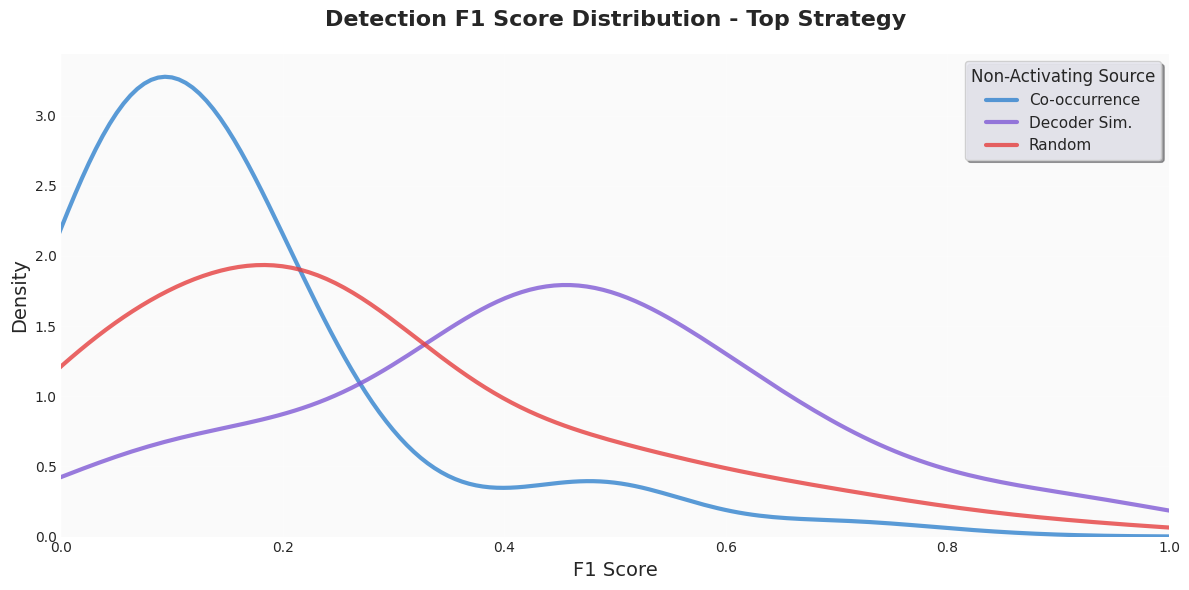

Saved KDE plot: /home/jeremias/projects/delphi-explanations/results/visualizations/contrastive_experiments/contrastive_kde_detection_top.pdf
Generating KDE plots for fuzz...


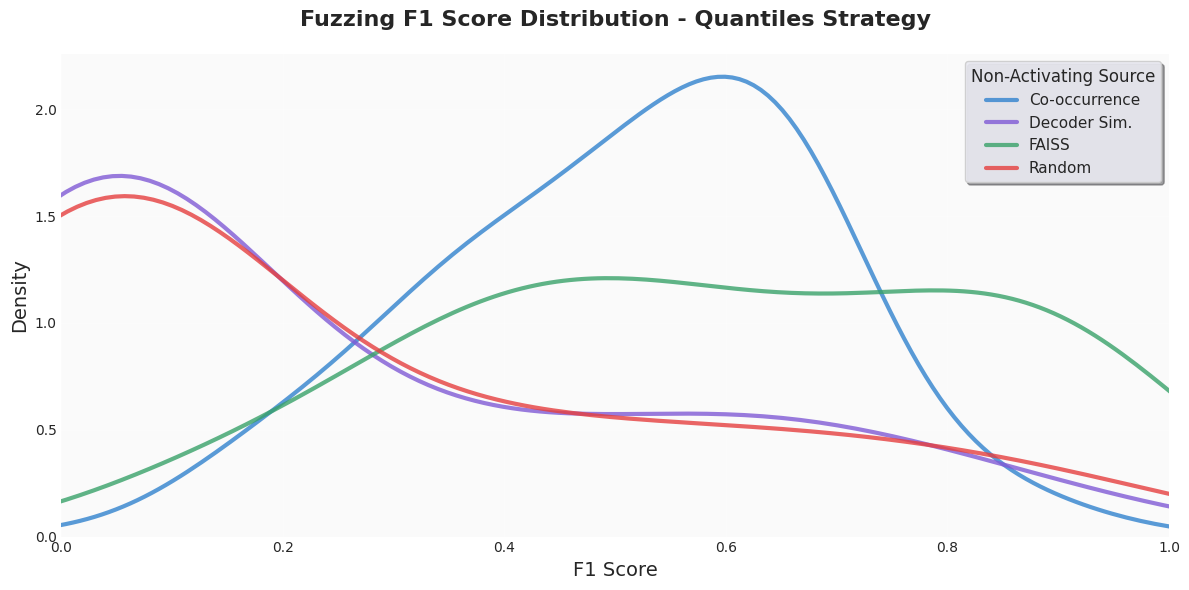

Saved KDE plot: /home/jeremias/projects/delphi-explanations/results/visualizations/contrastive_experiments/contrastive_kde_fuzz_quantiles.pdf


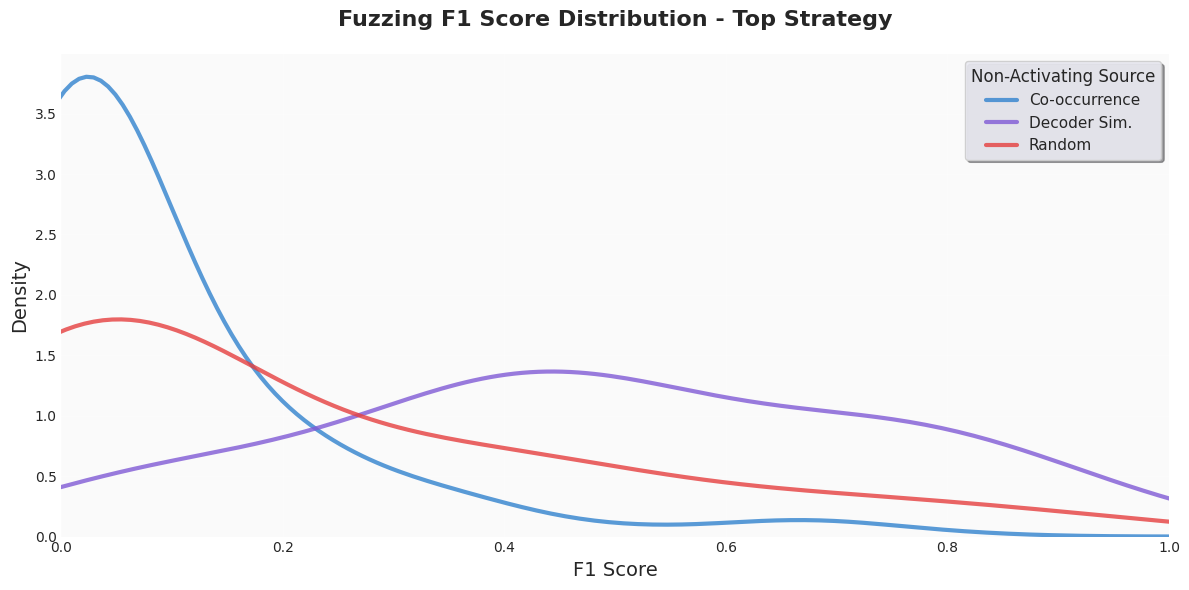

Saved KDE plot: /home/jeremias/projects/delphi-explanations/results/visualizations/contrastive_experiments/contrastive_kde_fuzz_top.pdf

KDE plots saved to /home/jeremias/projects/delphi-explanations/results/visualizations/contrastive_experiments


In [10]:
def prepare_kde_data(experiment_results, score_type):
    """Prepare data for KDE plots by extracting per-latent F1 scores."""
    kde_data = []
    
    for exp_name, data in experiment_results.items():
        latent_df = data['latent_df']
        counts = data['counts']
        config = data['config']
        
        # Filter for the specific score type
        score_subset = latent_df[latent_df['score_type'] == score_type]
        
        if len(score_subset) == 0 or counts is None:
            continue
        
        # Extract per-latent F1 scores
        for (module, latent_idx), grp in score_subset.groupby(["module", "latent_idx"]):
            if module in counts and latent_idx < len(counts[module]):
                f1 = compute_classification_metrics(compute_confusion(grp))["f1_score"]
                firing_count = counts[module][latent_idx].item()
                
                kde_data.append({
                    'experiment': exp_name,
                    'source': config['source'],
                    'ranking': config['ranking'],
                    'mode': config['mode'],
                    'f1_score': float(f1),
                    'firing_count': float(firing_count),
                    'module': module,
                    'latent_idx': latent_idx
                })
    
    return pd.DataFrame(kde_data)

# Set up matplotlib style for KDE plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Generate separate KDE plots for each ranking strategy
for score_type in all_score_types:
    print(f"Generating KDE plots for {score_type}...")
    
    kde_data = prepare_kde_data(experiment_results, score_type)
    
    if kde_data.empty:
        print(f"No data available for {score_type} KDE plot")
        continue
    
    # Create separate plots for each ranking strategy
    ranking_strategies = ['quantiles', 'top']
    
    for ranking_strategy in ranking_strategies:
        ranking_data = kde_data[kde_data['ranking'] == ranking_strategy]
        
        if ranking_data.empty:
            print(f"No data for {ranking_strategy} strategy in {score_type}")
            continue
        
        # Create figure comparing all sources for this ranking strategy
        fig, ax = plt.subplots(1, 1, figsize=(12, 6))
        
        sources = sorted(ranking_data['source'].unique())
        
        for source in sources:
            source_data = ranking_data[ranking_data['source'] == source]
            
            if len(source_data) > 0:
                # Weight by firing count for the KDE
                weights = source_data['firing_count'].values
                weights = weights / weights.sum()  # Normalize weights
                
                # Create KDE plot with clean labels
                source_label = SOURCE_DISPLAY.get(source, source)
                sns.kdeplot(
                    data=source_data,
                    x='f1_score',
                    weights=weights,
                    ax=ax,
                    label=source_label,
                    color=SOURCE_COLORS.get(source, '#808080'),
                    linewidth=3,
                    alpha=0.8
                )
        
        # Styling
        ranking_display = RANKING_DISPLAY.get(ranking_strategy, ranking_strategy)
        ax.set_title(f'{score_display_name(score_type)} F1 Score Distribution - {ranking_display} Strategy', 
                     fontsize=16, fontweight='bold', pad=20)
        ax.set_xlabel('F1 Score', fontsize=14, fontweight='medium')
        ax.set_ylabel('Density', fontsize=14, fontweight='medium')
        ax.legend(title='Non-Activating Source', title_fontsize=12, fontsize=11, frameon=True, 
                 fancybox=True, shadow=True, framealpha=0.9)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0, 1)
        
        # Add subtle background styling
        ax.set_facecolor('#FAFAFA')
        
        plt.tight_layout()
        
        # Show the plot
        plt.show()
        
        # Save the plot
        output_file_pdf = visualizations_dir / f"contrastive_kde_{score_type}_{ranking_strategy}.pdf"
        output_file_png = visualizations_dir / f"contrastive_kde_{score_type}_{ranking_strategy}.png"
        plt.savefig(str(output_file_pdf), dpi=300, bbox_inches='tight', facecolor='white')
        plt.savefig(str(output_file_png), dpi=300, bbox_inches='tight', facecolor='white')
        print(f"Saved KDE plot: {output_file_pdf}")
        
        plt.close()

print(f"\nKDE plots saved to {visualizations_dir}")

## 5. Comprehensive Performance Summary

Display summary tables and identify the best performing configurations across different metrics.

In [11]:
# Create comprehensive performance summary
print("Creating comprehensive performance summary...")

summary_rows = []
for exp_name, data in experiment_results.items():
    processed_df = data['processed_df']
    config = data['config']
    
    # Compute mean metrics across score types
    mean_metrics = {
        'experiment': config['display_name'],  # Use clean display name
        'source': config['source'],
        'ranking': config['ranking'],
        'mode': config['mode'],
        'mean_frequency_weighted_f1': processed_df['weighted_f1'].mean() if 'weighted_f1' in processed_df.columns else None,
        'mean_accuracy': processed_df['accuracy'].mean(),
        'mean_precision': processed_df['precision'].mean(),
        'mean_recall': processed_df['recall'].mean(),
        'mean_f1': processed_df['f1_score'].mean()
    }
    
    # Add per-score-type metrics
    for _, row in processed_df.iterrows():
        score_type = row['score_type']
        mean_metrics[f'{score_type}_frequency_weighted_f1'] = row.get('weighted_f1')
        mean_metrics[f'{score_type}_accuracy'] = row['accuracy']
        mean_metrics[f'{score_type}_f1'] = row['f1_score']
    
    summary_rows.append(mean_metrics)

summary_df = pd.DataFrame(summary_rows)

# Sort by mean frequency-weighted F1
summary_df = summary_df.sort_values('mean_frequency_weighted_f1', ascending=False)

print("\nContrastive Experiments Performance Summary:")
print("=" * 80)
display_cols = ['experiment', 'source', 'ranking', 'mode', 'mean_frequency_weighted_f1', 'mean_accuracy', 'mean_f1']
print(summary_df[display_cols].round(3))

# Save detailed summary to CSV
summary_file = visualizations_dir / "contrastive_experiments_summary.csv"
summary_df.to_csv(summary_file, index=False)
print(f"\nDetailed summary saved to: {summary_file}")

# Best performing configurations by category
print("\nBest Performing Configurations:")
print("=" * 50)

if 'mean_frequency_weighted_f1' in summary_df.columns and not summary_df['mean_frequency_weighted_f1'].isna().all():
    best_overall = summary_df.loc[summary_df['mean_frequency_weighted_f1'].idxmax()]
    print(f"Highest Mean Frequency-Weighted F1: {best_overall['experiment']} ({best_overall['mean_frequency_weighted_f1']:.3f})")
    source_display = SOURCE_DISPLAY.get(best_overall['source'], best_overall['source'])
    ranking_display = RANKING_DISPLAY.get(best_overall['ranking'], best_overall['ranking'])
    print(f"  Source: {source_display}, Ranking: {ranking_display}, Mode: {best_overall['mode']}")

best_accuracy = summary_df.loc[summary_df['mean_accuracy'].idxmax()]
print(f"\nHighest Mean Accuracy: {best_accuracy['experiment']} ({best_accuracy['mean_accuracy']:.3f})")
source_display = SOURCE_DISPLAY.get(best_accuracy['source'], best_accuracy['source'])
ranking_display = RANKING_DISPLAY.get(best_accuracy['ranking'], best_accuracy['ranking'])
print(f"  Source: {source_display}, Ranking: {ranking_display}, Mode: {best_accuracy['mode']}")

# Analysis by source
print("\nPerformance by Non-Activating Source:")
print("=" * 40)
source_summary = summary_df.groupby('source').agg({
    'mean_frequency_weighted_f1': ['mean', 'std'],
    'mean_accuracy': ['mean', 'std']
}).round(3)

# Rename the source index to use display names
source_summary.index = [SOURCE_DISPLAY.get(src, src) for src in source_summary.index]
print(source_summary)

# Analysis by ranking strategy
print("\nPerformance by Ranking Strategy:")
print("=" * 35)
ranking_summary = summary_df.groupby('ranking').agg({
    'mean_frequency_weighted_f1': ['mean', 'std'],
    'mean_accuracy': ['mean', 'std']
}).round(3)

# Rename the ranking index to use display names
ranking_summary.index = [RANKING_DISPLAY.get(rank, rank) for rank in ranking_summary.index]
print(ranking_summary)

print(f"\nAll visualizations and summaries saved to: {visualizations_dir}")
print("\nGenerated files:")
for file in sorted(visualizations_dir.glob("*")):
    print(f"  - {file.name}")

Creating comprehensive performance summary...

Contrastive Experiments Performance Summary:
                  experiment              source    ranking         mode  \
0          FAISS (Quantiles)               faiss  quantiles  contrastive   
1  Co-occurrence (Quantiles)       co-occurrence  quantiles  contrastive   
4         Decoder Sim. (Top)  decoder_similarity        top  contrastive   
5         Random (Quantiles)              random  quantiles     baseline   
2   Decoder Sim. (Quantiles)  decoder_similarity  quantiles  contrastive   
6               Random (Top)              random        top     baseline   
3        Co-occurrence (Top)       co-occurrence        top  contrastive   

   mean_frequency_weighted_f1  mean_accuracy  mean_f1  
0                       0.610          0.774    0.763  
1                       0.554          0.644    0.667  
4                       0.465          0.707    0.643  
5                       0.287          0.638    0.490  
2                  